# Load and Evaluate Trained VAE Models

This notebook loads trained VAE models and evaluates them on the test set with balanced CNS and Spleen samples.


## Imports and Setup


In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["SCIPY_ARRAY_API"] = "1"
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys

# Add functions directory to path
sys.path.append('functions')
from vae_models import MultiModalConditionalVAE, SingleModalConditionalVAE

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")


Using device: cuda



## Configuration


In [ ]:
# Configuration
output_dir = 'output_cd'
target_label = 'label_tissue_converted'
batch_size = 64


## Load Data


In [9]:
print("=" * 60)
print("Loading Data")
print("=" * 60)

tcr_embs = pd.read_csv("tcr_embs.csv", index_col=0)
gex_df = pd.read_csv("gex_df.csv", index_col=0)
labels = pd.read_csv("labels.csv", index_col=0)

print(f"TCR embeddings shape: {tcr_embs.shape}")
print(f"Gene expression shape: {gex_df.shape}")
print(f"Labels shape: {labels.shape}")

# Ensure all DataFrames have the same index order
common_idx = tcr_embs.index.intersection(gex_df.index).intersection(labels.index)
tcr_embs = tcr_embs.loc[common_idx]
gex_df = gex_df.loc[common_idx]
labels = labels.loc[common_idx]

print(f"Common cells: {len(common_idx)}")


Loading Data
TCR embeddings shape: (40484, 1381)
Gene expression shape: (40484, 2995)
Labels shape: (40484, 6)
Common cells: 40484


In [20]:
# Prepare data
# Filter out rows with NaN tissue labels
valid_mask = labels['label_tissue'].notna()
print(f"Rows with valid tissue labels: {valid_mask.sum()} / {len(labels)}")

# Filter data
tcr_embs_filtered = tcr_embs.loc[valid_mask]
gex_df_filtered = gex_df.loc[valid_mask]
labels_filtered = labels.loc[valid_mask]
common_idx_filtered = labels_filtered.index

# Convert tissue labels to 3 classes: 'CNS', 'Spleen', and 'else'
def convert_tissue_label(tissue):
    if pd.isna(tissue):
        return 'else'
    tissue_str = str(tissue).strip()
    if tissue_str == 'CNS':
        return 'CNS'
    elif tissue_str == 'Spleen':
        return 'Spleen'
    else:
        return 'else'

labels_filtered = labels_filtered.copy()
labels_filtered['label_tissue_converted'] = labels_filtered['label_tissue'].apply(convert_tissue_label)

print(f"\nTissue label distribution after conversion:")
print(labels_filtered['label_tissue_converted'].value_counts())



Rows with valid tissue labels: 38610 / 40484

Tissue label distribution after conversion:
label_tissue_converted
Spleen    26537
CNS        8541
else       3532
Name: count, dtype: int64


In [21]:
labels_filtered.head(5)

,label_tissue,label_cell_type,label_state,label_GSE,label_sample_id,label_set,label_tissue_converted
AAGTAGCAGATAGGCG-1_0516_CNS,CNS,CD4,Activation,LEE,5_7,train,CNS
AAGTATACACCCAGTA-1_0516_CNS,CNS,NaN,Activation,LEE,5_7,train,CNS
AAGTTTGGTGGAACCC-1_0516_CNS,CNS,NaN,Exhaust,LEE,5_3,train,CNS
AATTCGCCAGCTGTAT-1_0516_CNS,CNS,Treg,Activation,LEE,5_6,train,CNS
AGCAAGTAGAAATTGG-1_0516_CNS,CNS,Treg,Exhaust,LEE,5_3,train,CNS


## Preprocess Data (same as training)


In [22]:
print("\n" + "=" * 60)
print("Preprocessing Data")
print("=" * 60)

# Encode sample_id as one-hot
sample_id_encoder = LabelEncoder()
sample_id_encoded = sample_id_encoder.fit_transform(labels_filtered['label_sample_id'])
n_samples = len(sample_id_encoder.classes_)
sample_id_onehot = np.eye(n_samples)[sample_id_encoded]

# Encode target labels
tissue_encoder = LabelEncoder()
tissue_labels = tissue_encoder.fit_transform(labels_filtered[target_label])
n_tissues = len(tissue_encoder.classes_)

# Normalize features
tcr_scaler = StandardScaler()
gex_scaler = StandardScaler()

tcr_data = tcr_scaler.fit_transform(tcr_embs_filtered.values)
gex_data = gex_scaler.fit_transform(gex_df_filtered.values)

print(f"\nTCR data shape: {tcr_data.shape}")
print(f"GEX data shape: {gex_data.shape}")
print(f"Sample ID one-hot shape: {sample_id_onehot.shape}")
print(f"Number of tissue classes: {n_tissues}")
print(f"Tissue classes: {tissue_encoder.classes_}")



Preprocessing Data

TCR data shape: (38610, 1381)
GEX data shape: (38610, 2995)
Sample ID one-hot shape: (38610, 19)
Number of tissue classes: 3
Tissue classes: ['CNS' 'Spleen' 'else']


## Split Data and Balance Samples


In [30]:
# Split data: use label_set to separate train and test
train_mask = labels_filtered['label_set'] != 'test'
test_mask = labels_filtered['label_set'] == 'test'

train_idx = np.where(train_mask)[0]
test_idx = np.where(test_mask)[0]

print(f"Train size: {len(train_idx)}")
print(f"Test size: {len(test_idx)}")

# Create test splits
tcr_test = tcr_data[test_idx]
gex_test = gex_data[test_idx]
sample_id_test = sample_id_onehot[test_idx]
tissue_test = tissue_labels[test_idx]

# Filter test set to only include 'CNS' and 'Spleen' samples for balancing
test_tissue_labels = labels_filtered['label_tissue'].iloc[test_idx].values
cns_spleen_mask = np.isin(test_tissue_labels, ['CNS', 'Spleen'])

print(f"\nTest set tissue distribution before filtering:")
print(pd.Series(test_tissue_labels).value_counts())

if cns_spleen_mask.sum() > 0:
    # Filter to only CNS and Spleen
    tcr_test_filtered = tcr_test[cns_spleen_mask]
    gex_test_filtered = gex_test[cns_spleen_mask]
    sample_id_test_filtered = sample_id_test[cns_spleen_mask]
    tissue_test_filtered = tissue_test[cns_spleen_mask]
    test_tissue_labels_filtered = test_tissue_labels[cns_spleen_mask]
    
    print(f"\nFiltered test set size (CNS + Spleen only): {len(tcr_test_filtered)}")
    print(f"Tissue distribution in filtered test set:")
    print(pd.Series(test_tissue_labels_filtered).value_counts())
    
    # Balance samples using RandomOverSampler based on tissue type (CNS vs Spleen)
    ros = RandomOverSampler(random_state=42)
    
    # Create binary labels for balancing: 0 for CNS, 1 for Spleen
    binary_tissue_labels = (test_tissue_labels_filtered == 'Spleen').astype(int)
    
    # Balance each feature set separately to maintain alignment
    # For TCR features
    tcr_test_balanced, _ = ros.fit_resample(tcr_test_filtered, binary_tissue_labels)
    
    # For GEX features (same resampling)
    gex_test_balanced, binary_tissue_balanced = ros.fit_resample(gex_test_filtered, binary_tissue_labels)
    
    # For sample_id (same resampling)
    sample_id_test_balanced, _ = ros.fit_resample(sample_id_test_filtered, binary_tissue_labels)
    
    # For target labels (label_set) - keep aligned with resampled features
    tissue_test_balanced, _ = ros.fit_resample(tissue_test_filtered.reshape(-1, 1), binary_tissue_labels)
    tissue_test_balanced = tissue_test_balanced.flatten()
    
    # Reconstruct tissue names for reporting
    balanced_tissue_names = np.where(binary_tissue_balanced == 0, 'CNS', 'Spleen')
    
    print(f"\nAfter balancing:")
    print(f"Balanced test set size: {len(tcr_test_balanced)}")
    print(f"Tissue distribution in balanced test set:")
    print(pd.Series(balanced_tissue_names).value_counts())
    
    # Update test data with balanced samples
    tcr_test = tcr_test_balanced
    gex_test = gex_test_balanced
    sample_id_test = sample_id_test_balanced
    tissue_test = tissue_test_balanced
    
    print(f"\nUsing balanced test set with {len(tcr_test)} samples (CNS and Spleen only)")
else:
    print("\nWarning: No CNS or Spleen samples found in test set. Using original test set.")


Train size: 33078
Test size: 5532

Test set tissue distribution before filtering:
Spleen    4253
CNS       1279
Name: count, dtype: int64

Filtered test set size (CNS + Spleen only): 5532
Tissue distribution in filtered test set:
Spleen    4253
CNS       1279
Name: count, dtype: int64

After balancing:
Balanced test set size: 8506
Tissue distribution in balanced test set:
CNS       4253
Spleen    4253
Name: count, dtype: int64

Using balanced test set with 8506 samples (CNS and Spleen only)


## Load Models


In [31]:
print("\n" + "=" * 60)
print("Loading Trained Models")
print("=" * 60)

# Initialize models with same architecture as training
combined_model = MultiModalConditionalVAE(
    tcr_dim=tcr_data.shape[1],
    gex_dim=gex_data.shape[1],
    condition_dim=sample_id_onehot.shape[1],
    latent_dim=128,
    hidden_dim=512,
    n_classes=n_tissues
).to(device)

gex_model = SingleModalConditionalVAE(
    input_dim=gex_data.shape[1],
    condition_dim=sample_id_onehot.shape[1],
    latent_dim=128,
    hidden_dim=512,
    n_classes=n_tissues
).to(device)

tcr_model = SingleModalConditionalVAE(
    input_dim=tcr_data.shape[1],
    condition_dim=sample_id_onehot.shape[1],
    latent_dim=128,
    hidden_dim=512,
    n_classes=n_tissues
).to(device)

# Load model weights
combined_model.load_state_dict(torch.load(os.path.join(output_dir, 'combined_model.pth'), map_location=device))
gex_model.load_state_dict(torch.load(os.path.join(output_dir, 'gex_model.pth'), map_location=device))
tcr_model.load_state_dict(torch.load(os.path.join(output_dir, 'tcr_model.pth'), map_location=device))

print("All models loaded successfully!")



Loading Trained Models
All models loaded successfully!


## Evaluation Function


In [32]:
def evaluate_model(model, test_loader, model_name, is_multimodal=True):
    """Evaluate model and return predictions"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        if is_multimodal:
            # Combined model
            for tcr_batch, gex_batch, condition_batch, tissue_batch in test_loader:
                tcr_batch = tcr_batch.to(device)
                gex_batch = gex_batch.to(device)
                condition_batch = condition_batch.to(device)
                _, _, _, _, _, tissue_pred = model(tcr_batch, gex_batch, condition_batch)
                _, predicted = torch.max(tissue_pred, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(tissue_batch.numpy())
        else:
            # Single modality model
            for x_batch, condition_batch, tissue_batch in test_loader:
                x_batch = x_batch.to(device)
                condition_batch = condition_batch.to(device)
                _, _, _, _, tissue_pred = model(x_batch, condition_batch)
                _, predicted = torch.max(tissue_pred, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(tissue_batch.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Get all possible class labels
    all_possible_labels = np.arange(len(tissue_encoder.classes_))
    class_names = [str(name) for name in tissue_encoder.classes_]
    accuracy = accuracy_score(all_labels, all_preds)
    
    print(f"\n{model_name} - Classification Report:")
    print(classification_report(all_labels, all_preds, 
                              labels=all_possible_labels,
                              target_names=class_names,
                              zero_division=0))
    print(f"{model_name} - Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    return all_preds, all_labels, accuracy


In [33]:
print("\n" + "=" * 60)
print("Creating Data Loaders")
print("=" * 60)

# Combined model test loader
combined_test_dataset = TensorDataset(
    torch.FloatTensor(tcr_test),
    torch.FloatTensor(gex_test),
    torch.FloatTensor(sample_id_test),
    torch.LongTensor(tissue_test)
)
combined_test_loader = DataLoader(combined_test_dataset, batch_size=batch_size, shuffle=False)

# GEX-only test loader
gex_test_dataset = TensorDataset(
    torch.FloatTensor(gex_test),
    torch.FloatTensor(sample_id_test),
    torch.LongTensor(tissue_test)
)
gex_test_loader = DataLoader(gex_test_dataset, batch_size=batch_size, shuffle=False)

# TCR-only test loader
tcr_test_dataset = TensorDataset(
    torch.FloatTensor(tcr_test),
    torch.FloatTensor(sample_id_test),
    torch.LongTensor(tissue_test)
)
tcr_test_loader = DataLoader(tcr_test_dataset, batch_size=batch_size, shuffle=False)

print(f"Test batches - Combined: {len(combined_test_loader)}, GEX: {len(gex_test_loader)}, TCR: {len(tcr_test_loader)}")



Creating Data Loaders
Test batches - Combined: 133, GEX: 133, TCR: 133


## Evaluate Models


In [34]:
print("\n" + "=" * 60)
print("EVALUATING MODELS ON TEST SET")
print("=" * 60)

# Evaluate all models
combined_preds, combined_labels, combined_acc = evaluate_model(
    combined_model, combined_test_loader, "Combined (GEX+TCR)", is_multimodal=True
)

gex_preds, gex_labels, gex_acc = evaluate_model(
    gex_model, gex_test_loader, "GEX-only", is_multimodal=False
)

tcr_preds, tcr_labels, tcr_acc = evaluate_model(
    tcr_model, tcr_test_loader, "TCR-only", is_multimodal=False
)



EVALUATING MODELS ON TEST SET

Combined (GEX+TCR) - Classification Report:
              precision    recall  f1-score   support

         CNS       0.99      0.83      0.90      4253
      Spleen       0.85      0.99      0.92      4253
        else       0.00      0.00      0.00         0

    accuracy                           0.91      8506
   macro avg       0.61      0.61      0.61      8506
weighted avg       0.92      0.91      0.91      8506

Combined (GEX+TCR) - Test Accuracy: 0.9095 (90.95%)

GEX-only - Classification Report:
              precision    recall  f1-score   support

         CNS       0.99      0.74      0.85      4253
      Spleen       0.79      0.99      0.88      4253
        else       0.00      0.00      0.00         0

    accuracy                           0.87      8506
   macro avg       0.60      0.58      0.58      8506
weighted avg       0.89      0.87      0.87      8506

GEX-only - Test Accuracy: 0.8680 (86.80%)

TCR-only - Classification Report

## Summary


In [35]:
print("\n" + "=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"{'Model':<25} {'Test Accuracy':<15}")
print("-" * 40)
print(f"{'Combined (GEX+TCR)':<25} {combined_acc*100:>13.2f}%")
print(f"{'GEX-only':<25} {gex_acc*100:>13.2f}%")
print(f"{'TCR-only':<25} {tcr_acc*100:>13.2f}%")
print("=" * 60)



EVALUATION SUMMARY
Model                     Test Accuracy  
----------------------------------------
Combined (GEX+TCR)                90.95%
GEX-only                          86.80%
TCR-only                          14.15%


## Confusion Matrices



Generating Confusion Matrices
Confusion matrices saved to 'output_cd\confusion_matrices.png'


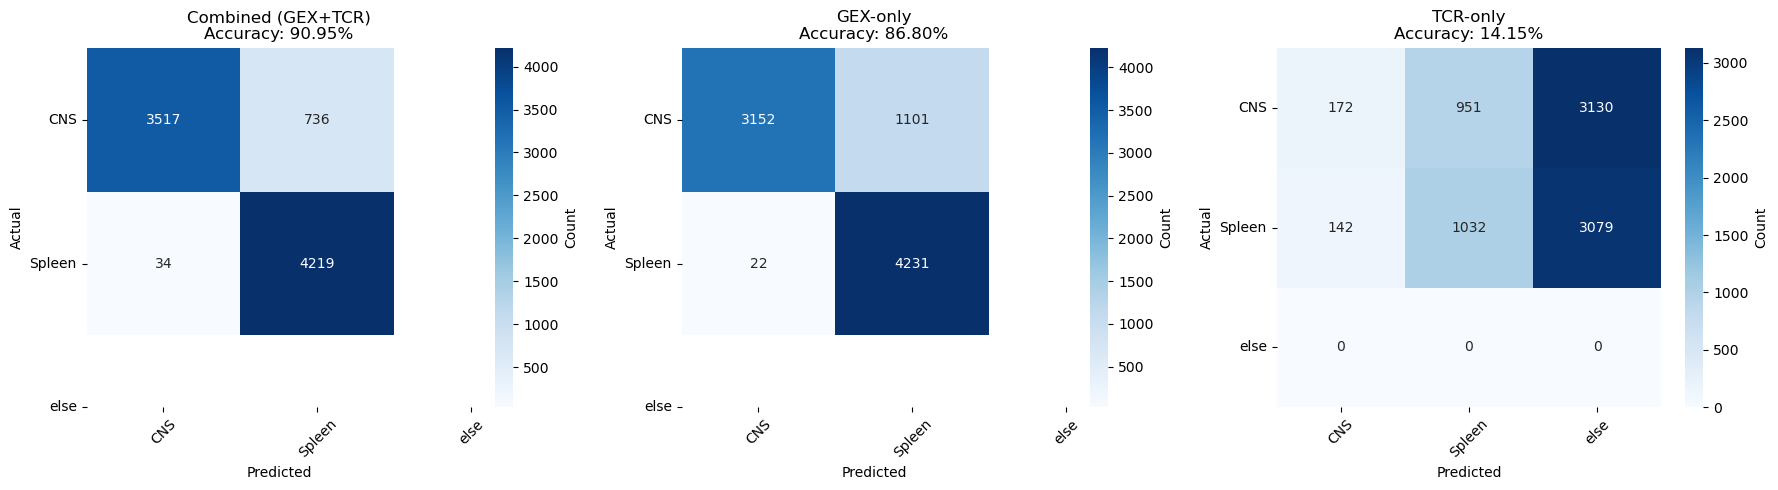

In [36]:
print("\n" + "=" * 60)
print("Generating Confusion Matrices")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = [str(name) for name in tissue_encoder.classes_]

models_data = [
    (combined_preds, combined_labels, "Combined (GEX+TCR)", combined_acc),
    (gex_preds, gex_labels, "GEX-only", gex_acc),
    (tcr_preds, tcr_labels, "TCR-only", tcr_acc)
]

for idx, (preds, labels, title, acc) in enumerate(models_data):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar_kws={'label': 'Count'})
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_title(f'{title}\nAccuracy: {acc*100:.2f}%')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'confusion_matrices.png'), dpi=300, bbox_inches='tight')
print(f"Confusion matrices saved to '{os.path.join(output_dir, 'confusion_matrices.png')}'")
plt.show()


## Save Predictions


In [37]:
print("\n" + "=" * 60)
print("Saving Predictions")
print("=" * 60)

# Note: For balanced test set, we need to handle index differently
# Since we resampled, we'll create a new index
if 'tcr_test_balanced' in locals():
    # Create new index for balanced samples
    balanced_indices = [f"balanced_{i}" for i in range(len(combined_preds))]
    predictions_df = pd.DataFrame({
        'combined_pred': combined_preds,
        'gex_pred': gex_preds,
        'tcr_pred': tcr_preds,
        'true_label': combined_labels
    }, index=balanced_indices)
else:
    predictions_df = pd.DataFrame({
        'combined_pred': combined_preds,
        'gex_pred': gex_preds,
        'tcr_pred': tcr_preds,
        'true_label': combined_labels
    }, index=labels_filtered.index[test_idx])

predictions_filepath = os.path.join(output_dir, 'test_predictions.csv')
predictions_df.to_csv(predictions_filepath, index=True)
print(f"Predictions saved to '{predictions_filepath}'")

# Save evaluation results
results_df = pd.DataFrame({
    'Model': ['Combined (GEX+TCR)', 'GEX-only', 'TCR-only'],
    'Test_Accuracy': [combined_acc * 100, gex_acc * 100, tcr_acc * 100]
})

results_filepath = os.path.join(output_dir, 'evaluation_results.csv')
results_df.to_csv(results_filepath, index=False)
print(f"Evaluation results saved to '{results_filepath}'")

print("\n" + "=" * 60)
print("EVALUATION COMPLETE")
print("=" * 60)



Saving Predictions
Predictions saved to 'output_cd\test_predictions.csv'
Evaluation results saved to 'output_cd\evaluation_results.csv'

EVALUATION COMPLETE
